# 04 - Giá trị thiếu, mẫu bất thường và ngoại lệ
**Phụ trách: Lưu Lương Mạnh Dũng (TV4)**.

In [1]:
import sys; sys.path.append('../src')
from eda_utils import *
train, test = load()
print(train.shape, test.shape)

(1460, 81) (1459, 80)


## 1. Cảnh báo khi đọc file: chữ `None` bị pandas coi là thiếu
Trong `MasVnrType`, `None` (không ốp tường) là một nhóm hợp lệ. Với `pd.read_csv` mặc định (pandas >= 2.0), chữ 'None' bị coi là NaN nên cột này báo thiếu ~60%.

In [2]:
bad = pd.read_csv(f'{DATA}/train.csv')                       # cách đọc mặc định
print('Đọc mặc định   : MasVnrType thiếu =', bad.MasVnrType.isna().sum(), f'({bad.MasVnrType.isna().mean():.1%}); mode =', bad.MasVnrType.mode()[0])
print('Đọc đúng cách  : MasVnrType thiếu =', train.MasVnrType.isna().sum(), f'({train.MasVnrType.isna().mean():.1%}); giá trị:', train.MasVnrType.value_counts().to_dict())
print('=> Điền mode với cách đọc mặc định sẽ biến ~864 căn "None" thành "BrkFace" (sai).')

Đọc mặc định   : MasVnrType thiếu = 872 (59.7%); mode = BrkFace
Đọc đúng cách  : MasVnrType thiếu = 8 (0.5%); giá trị: {'None': 864, 'BrkFace': 445, 'Stone': 128, 'BrkCmn': 15}
=> Điền mode với cách đọc mặc định sẽ biến ~864 căn "None" thành "BrkFace" (sai).


## 2. Thống kê giá trị thiếu (train và test)

In [3]:
def miss(df):
    m = df.isna().sum(); m = m[m > 0].sort_values(ascending=False)
    return pd.DataFrame({'thieu': m, 'ty_le_%': (m / len(df) * 100).round(1)})
mt, ms = miss(train), miss(test)
mt['Nhóm'] = ['NA = không có' if c in NA_MEANS_NONE else ('Đi kèm không có garage' if c == 'GarageYrBlt' else 'Thiếu thật (cần điền)') for c in mt.index]
display(mt); print('Test: số cột thiếu =', len(ms), '| train:', len(mt))
mt.to_csv(f'{RES}/thieu_train.csv', encoding='utf-8-sig'); ms.to_csv(f'{RES}/thieu_test.csv', encoding='utf-8-sig')

,thieu,ty_le_%,Nhóm
PoolQC,1453,99.5,NA = không có
MiscFeature,1406,96.3,NA = không có
Alley,1369,93.8,NA = không có
Fence,1179,80.8,NA = không có
FireplaceQu,690,47.3,NA = không có
LotFrontage,259,17.7,Thiếu thật (cần điền)
GarageCond,81,5.5,NA = không có
GarageType,81,5.5,NA = không có
GarageYrBlt,81,5.5,Đi kèm không có garage
GarageFinish,81,5.5,NA = không có


Test: số cột thiếu = 33 | train: 19


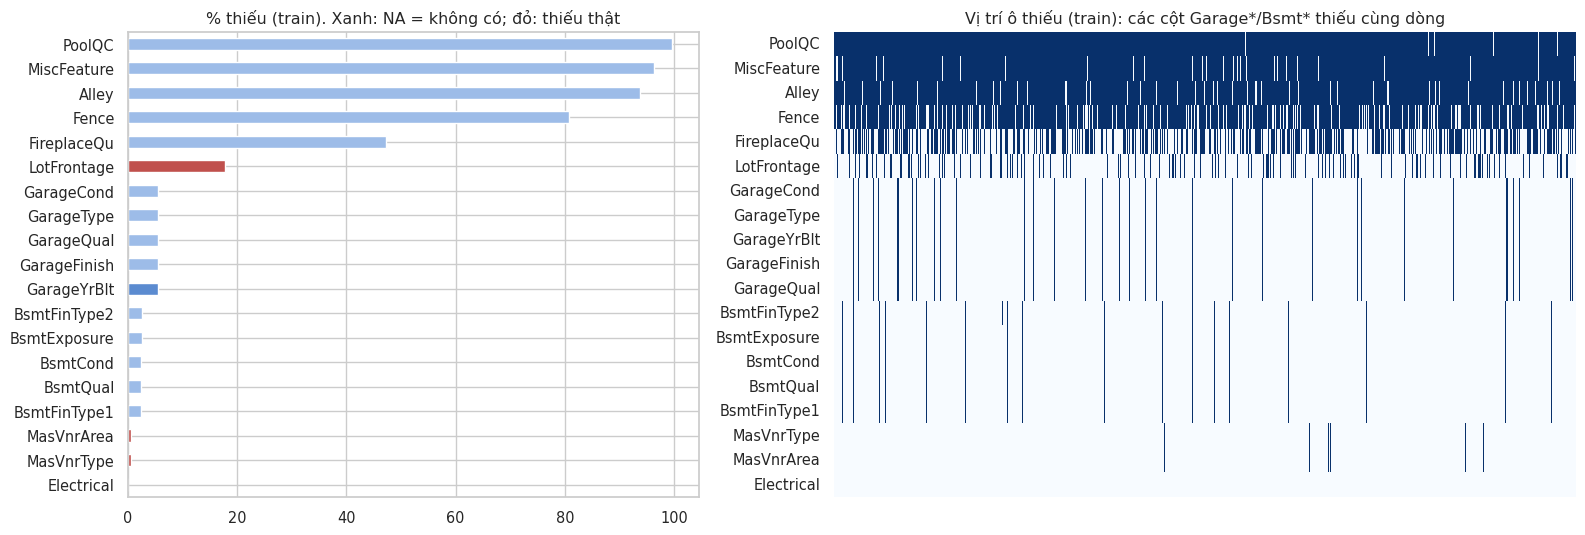

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [1, 1.3]})
colr = mt.Nhóm.map({'NA = không có': '#9DBCE8', 'Đi kèm không có garage': '#5B8BD0', 'Thiếu thật (cần điền)': '#C0504D'})
mt['ty_le_%'].sort_values().plot.barh(ax=ax[0], color=colr.reindex(mt['ty_le_%'].sort_values().index)); ax[0].set_title('% thiếu (train). Xanh: NA = không có; đỏ: thiếu thật')
sns.heatmap(train[mt.index].isna().T, cbar=False, ax=ax[1], xticklabels=False, cmap='Blues'); ax[1].set_title('Vị trí ô thiếu (train): các cột Garage*/Bsmt* thiếu cùng dòng')
save_fig('04_thieu')

## 3. Thiếu có ý nghĩa hay thiếu thật? Kiểm tra bằng quy tắc

In [5]:
def rules(df):
    g = df[['GarageType','GarageFinish','GarageQual','GarageCond','GarageYrBlt']]
    b = df[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']]
    return {
     'Garage*: NA nhưng GarageArea>0 (thiếu thật)': int(((df.GarageArea > 0) & g.isna().any(axis=1)).sum()),
     'Garage*: NA hoàn toàn nhưng GarageArea=0/NaN (hợp lệ)': int(g.isna().all(axis=1).sum()),
     'Garage*: 5 cột thiếu cùng một dòng (tất cả hoặc không)': int((g.isna().sum(axis=1).isin([0, 5])).sum()),
     'Bsmt*: NA nhưng TotalBsmtSF>0 (thiếu thật)': int(((df.TotalBsmtSF > 0) & b.isna().any(axis=1)).sum()),
     'FireplaceQu NA nhưng Fireplaces>0': int(((df.Fireplaces > 0) & df.FireplaceQu.isna()).sum()),
     'FireplaceQu NA và Fireplaces=0 (hợp lệ)': int(((df.Fireplaces == 0) & df.FireplaceQu.isna()).sum()),
     'PoolQC NA nhưng PoolArea>0 (thiếu thật)': int(((df.PoolArea > 0) & df.PoolQC.isna()).sum()),
     'MasVnrType NA (thiếu thật, đi cùng MasVnrArea NA)': int(df.MasVnrType.isna().sum())}
rt = pd.DataFrame({'train': rules(train), 'test': rules(test)}); display(rt); rt.to_csv(f'{RES}/quy_tac_thieu.csv', encoding='utf-8-sig')
lf = train.groupby('Neighborhood').LotFrontage.agg(['count', 'median', lambda s: s.isna().sum()]); lf.columns = ['co_gia_tri', 'median', 'thieu']
print('LotFrontage thiếu theo Neighborhood (5 nơi nhiều nhất):'); display(lf.sort_values('thieu', ascending=False).head(5))

,train,test
Garage*: NA nhưng GarageArea>0 (thiếu thật),0,1
Garage*: NA hoàn toàn nhưng GarageArea=0/NaN (hợp lệ),81,76
Garage*: 5 cột thiếu cùng một dòng (tất cả hoặc không),1460,1457
Bsmt*: NA nhưng TotalBsmtSF>0 (thiếu thật),2,7
FireplaceQu NA nhưng Fireplaces>0,0,0
FireplaceQu NA và Fireplaces=0 (hợp lệ),690,730
PoolQC NA nhưng PoolArea>0 (thiếu thật),0,3
"MasVnrType NA (thiếu thật, đi cùng MasVnrArea NA)",8,16


LotFrontage thiếu theo Neighborhood (5 nơi nhiều nhất):


,co_gia_tri,median,thieu
Neighborhood,,,
NAmes,186,73.0,39
Gilbert,49,65.0,30
NWAmes,45,80.0,28
Sawyer,48,71.0,26
CollgCr,126,70.0,24


## 4. Mẫu bất thường (kiểm tra logic)

In [6]:
def logic(df):
    return {
     'YearRemodAdd < YearBuilt': int((df.YearRemodAdd < df.YearBuilt).sum()),
     'YrSold < YearBuilt': int((df.YrSold < df.YearBuilt).sum()),
     'GarageYrBlt > YrSold': int((df.GarageYrBlt > df.YrSold).sum()),
     'GarageYrBlt > 2010 (năm không thể có)': int((df.GarageYrBlt > 2010).sum()),
     'GarageYrBlt < YearBuilt (garage cũ hơn nhà)': int((df.GarageYrBlt < df.YearBuilt).sum()),
     '1stFlr+2ndFlr+LowQual != GrLivArea': int(((df['1stFlrSF'] + df['2ndFlrSF'] + df.LowQualFinSF) != df.GrLivArea).sum()),
     'BsmtFin1+Fin2+Unf != TotalBsmtSF': int(((df.BsmtFinSF1 + df.BsmtFinSF2 + df.BsmtUnfSF) != df.TotalBsmtSF).sum()),
     'MasVnrType=None nhưng MasVnrArea>0': int(((df.MasVnrType == 'None') & (df.MasVnrArea > 0)).sum()),
     'MasVnrType khác None nhưng MasVnrArea=0': int(((df.MasVnrType.notna()) & (df.MasVnrType != 'None') & (df.MasVnrArea == 0)).sum()),
     'BedroomAbvGr=0': int((df.BedroomAbvGr == 0).sum()),
     'GrLivArea > 4000': int((df.GrLivArea > 4000).sum())}
lg = pd.DataFrame({'train': logic(train), 'test': logic(test)}); display(lg); lg.to_csv(f'{RES}/kiem_tra_logic.csv', encoding='utf-8-sig')
print(test.loc[test.GarageYrBlt > 2010, ['Id','YearBuilt','GarageYrBlt','YrSold']])

,train,test
YearRemodAdd < YearBuilt,0,1
YrSold < YearBuilt,0,1
GarageYrBlt > YrSold,0,2
GarageYrBlt > 2010 (năm không thể có),0,1
GarageYrBlt < YearBuilt (garage cũ hơn nhà),9,9
1stFlr+2ndFlr+LowQual != GrLivArea,0,0
BsmtFin1+Fin2+Unf != TotalBsmtSF,0,1
MasVnrType=None nhưng MasVnrArea>0,5,2
MasVnrType khác None nhưng MasVnrArea=0,2,1
BedroomAbvGr=0,6,2


        Id  YearBuilt  GarageYrBlt  YrSold
1132  2593       2006       2207.0    2007


In [7]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
cats = [c for c in feat if str(train[c].dtype)[:3] not in ('int','flo')]
rare = {c: [k for k, v in train[c].value_counts().items() if v < 0.01 * len(train)] for c in cats}
unseen = {c: sorted(set(test[c].dropna()) - set(train[c].dropna())) for c in cats}; unseen = {k: v for k, v in unseen.items() if v}
print('Số nhóm hiếm (<1% dòng) tổng cộng:', sum(len(v) for v in rare.values()), 'ở', sum(1 for v in rare.values() if v), 'biến')
print('Nhóm chỉ có trong test (không có trong train):', unseen)
from scipy import stats
numf = [c for c in feat if c not in cats]
ks = pd.Series({c: stats.ks_2samp(train[c].dropna(), test[c].dropna()).pvalue for c in numf}).sort_values()
print('Biến số có phân phối train/test khác nhau (KS p<0.01):', ks[ks < 0.01].round(4).to_dict())

Số nhóm hiếm (<1% dòng) tổng cộng: 85 ở 31 biến
Nhóm chỉ có trong test (không có trong train): {}


Biến số có phân phối train/test khác nhau (KS p<0.01): {}


## 5. Ngoại lệ

Train: GrLivArea > 4000 -> 4 dòng


,Id,GrLivArea,TotalBsmtSF,OverallQual,SaleCondition,SalePrice
523,524,4676,3138,10,Partial,184750
691,692,4316,2444,10,Normal,755000
1182,1183,4476,2396,10,Abnorml,745000
1298,1299,5642,6110,10,Partial,160000


Test: GrLivArea > 4000 -> 1 dòng, Id = [2550]


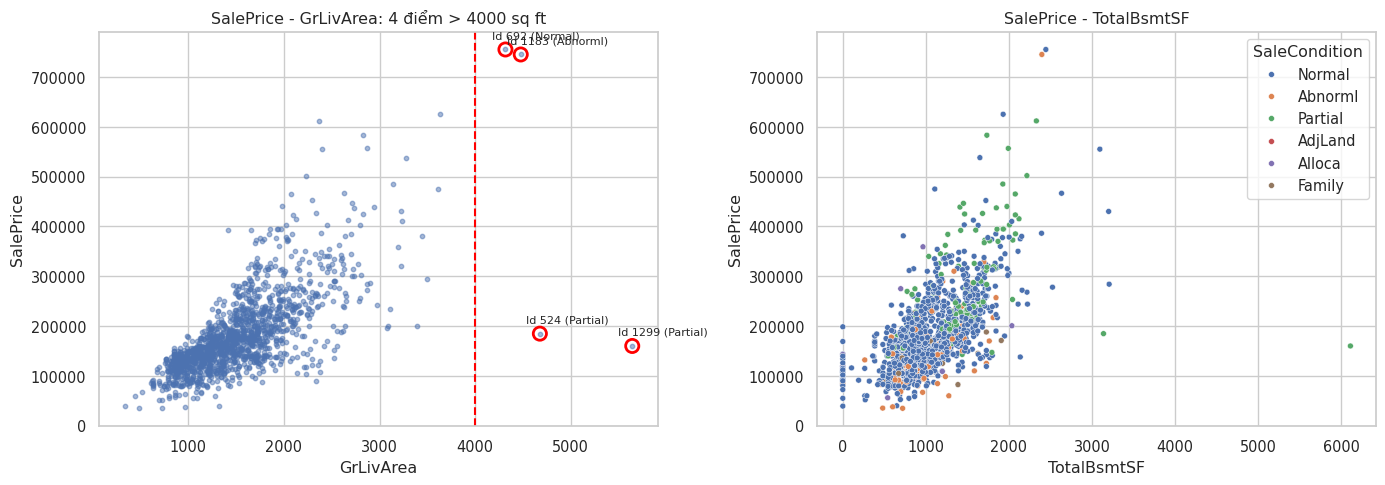

In [8]:
big = train[train.GrLivArea > 4000][['Id','GrLivArea','TotalBsmtSF','OverallQual','SaleCondition','SalePrice']]
print('Train: GrLivArea > 4000 ->', len(big), 'dòng'); display(big); print('Test: GrLivArea > 4000 ->', int((test.GrLivArea > 4000).sum()), 'dòng, Id =', test.loc[test.GrLivArea > 4000, 'Id'].tolist())
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(train.GrLivArea, train.SalePrice, s=10, alpha=.5); ax[0].scatter(big.GrLivArea, big.SalePrice, s=90, facecolors='none', edgecolors='red', lw=2)
for _, r in big.iterrows(): ax[0].annotate(f"Id {int(r.Id)} ({r.SaleCondition})", (r.GrLivArea, r.SalePrice), textcoords='offset points', xytext=(-10, 8), fontsize=8)
ax[0].axvline(4000, color='red', ls='--'); ax[0].set_title('SalePrice - GrLivArea: 4 điểm > 4000 sq ft'); ax[0].set_xlabel('GrLivArea'); ax[0].set_ylabel('SalePrice')
sns.scatterplot(data=train, x='TotalBsmtSF', y='SalePrice', hue='SaleCondition', ax=ax[1], s=18); ax[1].set_title('SalePrice - TotalBsmtSF')
save_fig('04_ngoai_le_scatter')

,IQR,Z>3
SalePrice,61,22
GrLivArea,31,16
LotArea,69,13
TotalBsmtSF,61,10
1stFlrSF,20,12
GarageArea,21,7
LotFrontage,88,12
MasVnrArea,96,32
BsmtFinSF1,7,6
WoodDeckSF,32,22


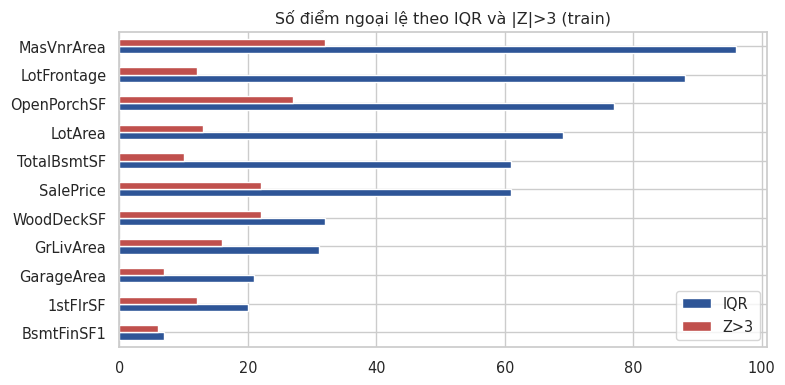

In [9]:
def iqr_out(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1; return int(((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum())
cols = ['SalePrice','GrLivArea','LotArea','TotalBsmtSF','1stFlrSF','GarageArea','LotFrontage','MasVnrArea','BsmtFinSF1','WoodDeckSF','OpenPorchSF']
z = ((train[cols] - train[cols].mean()) / train[cols].std()).abs()
ot = pd.DataFrame({'IQR': {c: iqr_out(train[c].dropna()) for c in cols}, 'Z>3': (z > 3).sum()}); display(ot)
fig, ax = plt.subplots(1, 1, figsize=(8, 4)); ot.sort_values('IQR').plot.barh(ax=ax, color=['#2E5597', '#C0504D']); ax.set_title('Số điểm ngoại lệ theo IQR và |Z|>3 (train)')
save_fig('04_ngoai_le_iqr')

Cook > 4/n = 0.0027: 82 điểm


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,cooks,stud
1298,1299,5642,10,Partial,160000,4.794,-14.344
523,524,4676,10,Partial,184750,0.445,-9.073
916,917,480,2,Abnorml,35311,0.021,-4.016
495,496,720,4,Abnorml,34900,0.020,-4.886
676,677,1774,4,Normal,87000,0.017,-2.567
30,31,1317,4,Normal,40000,0.015,-5.390
968,969,968,3,Abnorml,37900,0.014,-3.919
1062,1063,2337,5,Normal,90000,0.014,-2.925
457,458,1663,4,Normal,256000,0.012,3.434
728,729,1776,5,Abnorml,110000,0.012,-2.942


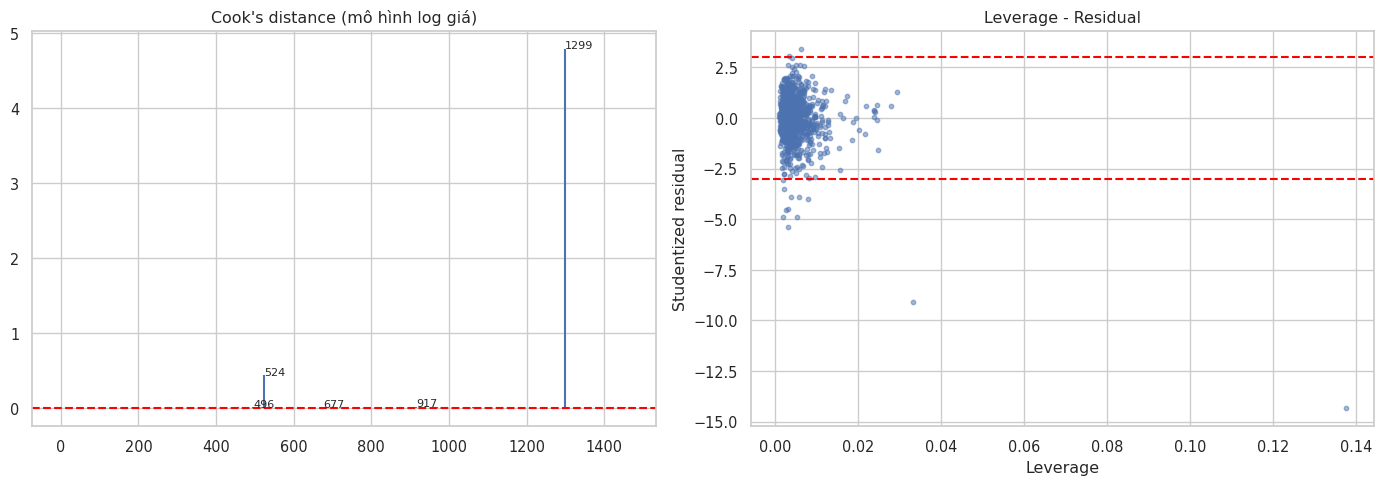

In [10]:
import statsmodels.formula.api as smf
fm = 'np.log(SalePrice) ~ GrLivArea + OverallQual + TotalBsmtSF + GarageCars + YearBuilt'
m = smf.ols(fm, train).fit(); inf = m.get_influence()
tr = train.assign(cooks=inf.cooks_distance[0], lev=inf.hat_matrix_diag, stud=inf.resid_studentized_external)
thr = 4 / len(tr); top = tr.sort_values('cooks', ascending=False).head(10)[['Id','GrLivArea','OverallQual','SaleCondition','SalePrice','cooks','stud']]
print(f'Cook > 4/n = {thr:.4f}: {(tr.cooks > thr).sum()} điểm'); display(top.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].stem(tr.index, tr.cooks, markerfmt=' ', basefmt=' '); ax[0].axhline(thr, color='red', ls='--'); ax[0].set_title("Cook's distance (mô hình log giá)")
for _, r in top.head(5).iterrows(): ax[0].annotate(int(r.Id), (tr.index[tr.Id == r.Id][0], r.cooks), fontsize=8)
ax[1].scatter(tr.lev, tr.stud, s=10, alpha=.5); ax[1].set_xlabel('Leverage'); ax[1].set_ylabel('Studentized residual'); ax[1].set_title('Leverage - Residual'); ax[1].axhline(3, color='red', ls='--'); ax[1].axhline(-3, color='red', ls='--')
save_fig('04_cooks')

In [11]:
clean = train[train.GrLivArea <= 4000]
def fit(df, f): r = smf.ols(f, df).fit(); return r
a = fit(train, 'SalePrice ~ GrLivArea'); b = fit(clean, 'SalePrice ~ GrLivArea'); a2 = fit(train, fm); b2 = fit(clean, fm)
cmp = pd.DataFrame({'Số dòng': [len(train), len(clean)], 'R2 (GrLivArea)': [a.rsquared, b.rsquared], 'Hệ số GrLivArea': [a.params['GrLivArea'], b.params['GrLivArea']],
                    'R2 (log giá, 5 biến)': [a2.rsquared, b2.rsquared]}, index=['Trước khi loại', 'Sau khi loại 4 điểm']); display(cmp.round(4))
ex = {'miss_count': mt['thieu'].to_dict(), 'n_rare_vars': int(sum(1 for v in rare.values() if v)), 'thr_cook': thr, 'n_train': len(train), 'n_clean': len(clean)}
print(ex)
save_json('nb04', {**ex, 'masvn_default_na': int(bad.MasVnrType.isna().sum()), 'masvn_default_pct': float(bad.MasVnrType.isna().mean() * 100), 'masvn_mode_bad': bad.MasVnrType.mode()[0],
  'masvn_true_na': int(train.MasVnrType.isna().sum()), 'masvn_none': int((train.MasVnrType == 'None').sum()), 'miss_train': mt['ty_le_%'].to_dict(), 'miss_group': mt.Nhóm.value_counts().to_dict(),
  'n_miss_cols_train': len(mt), 'n_miss_cols_test': len(ms), 'rules': rt.to_dict(), 'logic': lg.to_dict(), 'big_train': big.to_dict('records'), 'big_test_ids': test.loc[test.GrLivArea > 4000, 'Id'].tolist(),
  'outlier_counts': ot.to_dict(), 'cook_n': int((tr.cooks > thr).sum()), 'cook_top': top.head(5).round(3).to_dict('records'), 'cmp': cmp.round(4).to_dict('index'),
  'unseen_test_levels': unseen, 'rare_levels': sum(len(v) for v in rare.values()), 'ks_diff': ks[ks < 0.01].round(4).to_dict(),
  'lotfront_missing': int(train.LotFrontage.isna().sum())})

,Số dòng,R2 (GrLivArea),Hệ số GrLivArea,"R2 (log giá, 5 biến)"
Trước khi loại,1460,0.5021,107.1304,0.8119
Sau khi loại 4 điểm,1456,0.5191,111.2307,0.8445


{'miss_count': {'PoolQC': 1453, 'MiscFeature': 1406, 'Alley': 1369, 'Fence': 1179, 'FireplaceQu': 690, 'LotFrontage': 259, 'GarageCond': 81, 'GarageType': 81, 'GarageYrBlt': 81, 'GarageFinish': 81, 'GarageQual': 81, 'BsmtFinType2': 38, 'BsmtExposure': 38, 'BsmtCond': 37, 'BsmtQual': 37, 'BsmtFinType1': 37, 'MasVnrType': 8, 'MasVnrArea': 8, 'Electrical': 1}, 'n_rare_vars': 31, 'thr_cook': 0.0027397260273972603, 'n_train': 1460, 'n_clean': 1456}
